In [2]:
import numpy as np
from scipy.integrate import solve_ivp as sp_solve_ivp
from scipy.integrate import odeint
from tqdm.auto import tqdm
import torch
import torch.nn as nn
from typing import List
device = 'cpu'
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'serif'

from ftnode.utils import set_global_seed
from ftnode.node import (
    FTNODE, FeluSigmoidMLP, GeluSigmoidMLP,)

import torchode

seed = 1234
set_global_seed(seed)

random_state = 67

[Seed] Deterministic mode enabled (may reduce speed).


In [5]:
## Define system 
gamma = 50
def sigmoid(x,gamma=gamma):
    return 1 / (1+np.exp(-gamma*x))

eps = 0.02
q1, q2 = (0.08, 0.04)
b1 = 1-eps
b2 = 1-eps

def c1_in(x):
    return q1*(1-sigmoid(x-b1))

def c2_in(y):
    return q1*(1-sigmoid(y-b2))

def c1_out(y):
    return q2*(1-sigmoid(y-b2))

def c2_out(y):
    return q2

def two_tank_system(t,x,u):
    x1, x2 = x
    p, v = u
    x1= np.maximum(x1,0)
    x2 = np.maximum(x2,0)
    dx1dt = c1_in(x1)*(1-v)*p-c1_out(x2)*np.sqrt(x1)
    dx2dt = c2_in(x2)*v*p +c1_out(x2)*np.sqrt(x1)-q2*np.sqrt(x2)
    return np.hstack([dx1dt,dx2dt])


p_vals = np.linspace(0,1,101)
v_vals = np.linspace(0,1,101)

In [ ]:
f = FeluSigmoidMLP(dims=[2,20,20,20,2],lower_bound=-1, upper_bound=-0.1)
g = GeluSigmoidMLP(dims=[4,20,20,20,2],lower_bound=0, upper_bound=1)
model = FTNODE(f,g).to(device)

model_path = "../best_model-20-20-20.pth"

model.load_state_dict(torch.load(model_path))

model.eval()

FTNODE(
  (f): FeluSigmoidMLP(
    (activation): SiLU()
    (network): MLP(
      (activation): SiLU()
      (layers): ModuleList(
        (0): Linear(in_features=2, out_features=20, bias=True)
        (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
        (3): Linear(in_features=20, out_features=2, bias=True)
      )
    )
  )
  (g): GeluSigmoidMLP(
    (activation): SiLU()
    (network): MLP(
      (activation): SiLU()
      (layers): ModuleList(
        (0): Linear(in_features=4, out_features=20, bias=True)
        (1-2): 2 x Linear(in_features=20, out_features=20, bias=True)
        (3): Linear(in_features=20, out_features=2, bias=True)
      )
    )
  )
)

In [7]:
# Given parameters
from scipy.optimize import root
t_span = (0, 1500)

pi = .5
vi = 0.5

p_vals = np.linspace(0,1,5)
v_vals = np.linspace(0,1,5)
p_vals[0] = 0.05
v_vals[0] = 0.05
p_vals[-1] = 0.95
v_vals[-1] = 0.95

x_inits = [[0.1,0.1],[.9,0.2],[0.2,.9],[0.1,0.6],[0.6,0.1],[0.8,0.8]]

n_points = 21
eps = 1e-2

x1_lin = np.linspace(0, 1+eps, n_points)
x2_lin = np.linspace(0, 1+eps, n_points)
X1, X2 = np.meshgrid(x1_lin, x2_lin)

prev_eq = np.array([0.5,0.5])

  0%|          | 0/5 [00:00<?, ?it/s]

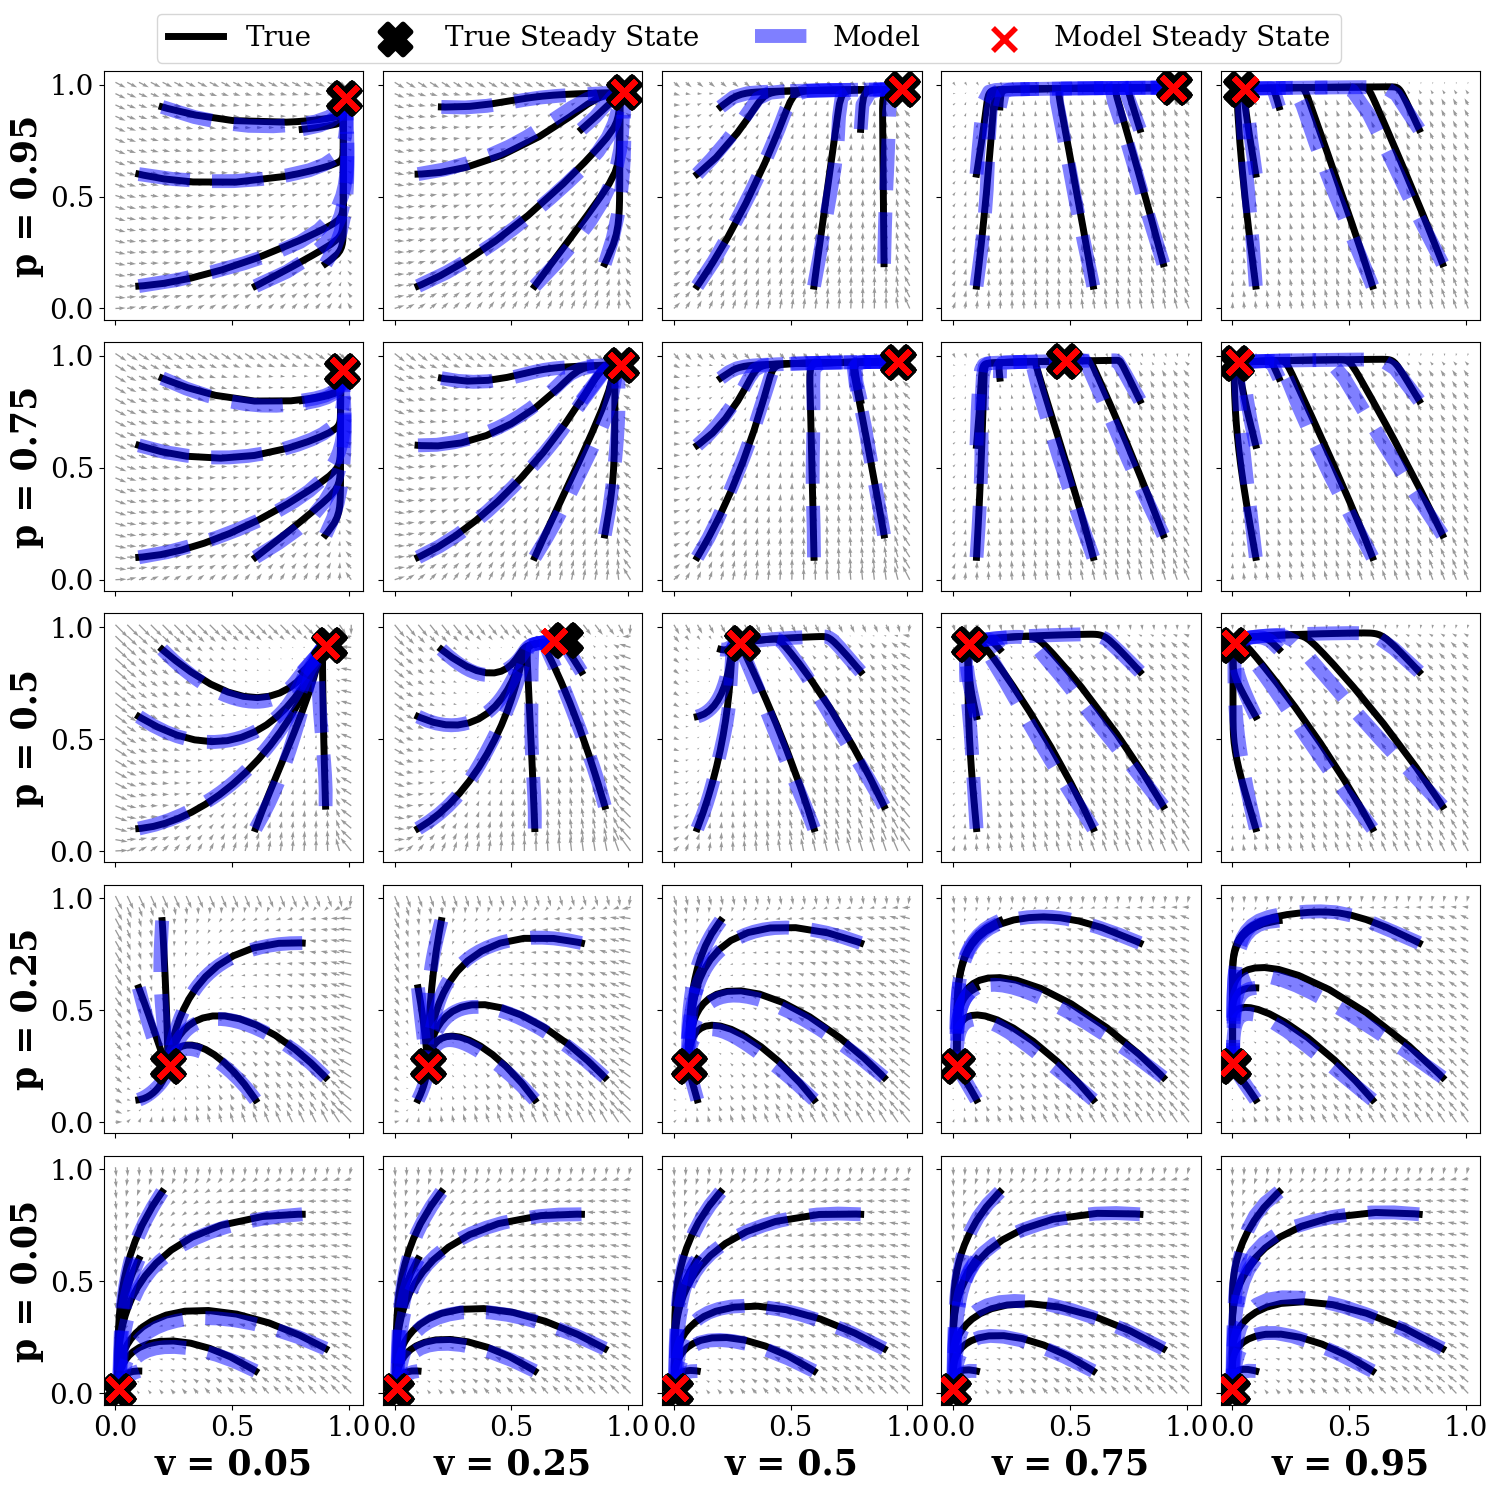

In [ ]:
fig_scale = 3
figsize = (int(fig_scale*len(p_vals)), int(fig_scale*len(v_vals)))

fig, axes = plt.subplots(
    len(p_vals), len(v_vals),
    figsize=figsize,
    # constrained_layout=True,
    sharex=True,
    sharey=True
)

Ti = torch.linspace(t_span[0], t_span[-1], 501, dtype=torch.float32)

for i, pi in enumerate(tqdm(p_vals[::-1])):
    for j, vj in enumerate(v_vals):
        ax = axes[i, j]

        # ======================================================
        # TRUE VECTOR FIELD
        # ======================================================
        U = np.zeros_like(X1)
        V = np.zeros_like(X2)

        for ii in range(X1.shape[0]):
            for jj in range(X1.shape[1]):
                x = np.array([X1[ii, jj], X2[ii, jj]])
                dxdt = two_tank_system(0, x, (pi, vj))
                U[ii, jj] = dxdt[0]
                V[ii, jj] = dxdt[1]

        ax.quiver(
            X1, X2, U, V,
            angles='xy',
            scale_units='xy',
            width=0.005,
            color='grey',
            alpha=0.8
        )

        # ======================================================
        # TRUE TRAJECTORIES (solid)
        # ======================================================
        for idx, x0 in enumerate(x_inits):
            label = None
            if idx ==0:
                label = "True"
            sol_true = sp_solve_ivp(
                lambda t, y: two_tank_system(t, y, (pi, vj)),
                t_span,
                x0,
                rtol=1e-6,
                atol=1e-9
            )

            ax.plot(
                sol_true.y[0],
                sol_true.y[1],
                '-',
                c='black',
                lw=5,
                zorder=2,
                label=label
            )
            label=None
            if idx ==0:
                label = "True Steady State"
            x_last = sol_true.y[:, -1]
            ax.scatter(
                x_last[0], x_last[1],
                marker='X',
                s=475,
                c='black',
                lw=4,
                zorder=3,
                label=label
            )

        # ======================================================
        # MODEL TRAJECTORIES (dashed)
        # ======================================================
        x0_torch = torch.tensor(x_inits, dtype=torch.float32)
        n_x0, dim_x0 = x0_torch.shape

        control = lambda t: torch.tensor([pi, vj], dtype=torch.float32).expand(n_x0, dim_x0)
        func = lambda t, x: model(t, x, control)

        with torch.no_grad():
            sol_model = torchode.solve_ivp(
                f=func,
                y0=x0_torch,
                t_eval=Ti,
            )

        for idx,traj in enumerate(sol_model.ys):
            label=None
            if idx ==0:
                label = "Model"
            ax.plot(
                traj[:, 0].numpy(),
                traj[:, 1].numpy(),
                '--',              # <-- dashed
                lw=10,
                color='blue',
                alpha=0.5,
                zorder=2,
                label = label
            )
            x_last = traj[-1,:].numpy()
            
            label = None
            if idx ==0:
                label = "Model Steady State"
            ax.scatter(x_last[0],x_last[1], marker='x',s=275,c='red',lw=4,zorder=4,label =label)


        # ======================================================
        # LABELS / FORMATTING
        # ======================================================
        if j == 0:
            ax.set_ylabel(f"p = {pi}", size=25, fontweight='bold')

        if i == len(v_vals) - 1:
            ax.set_xlabel(f"v = {vj}", size=25, fontweight='bold')

        ax.tick_params(axis='both', which='major', labelsize=20)

# plt.suptitle(
#     "Phase Portrait: True System (solid) vs Model (dashed)",
#     size=60
# )

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5,fontsize=20)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig("mixing-tanks-phase-portrait.png")
plt.show()


  0%|          | 0/5 [00:00<?, ?it/s]

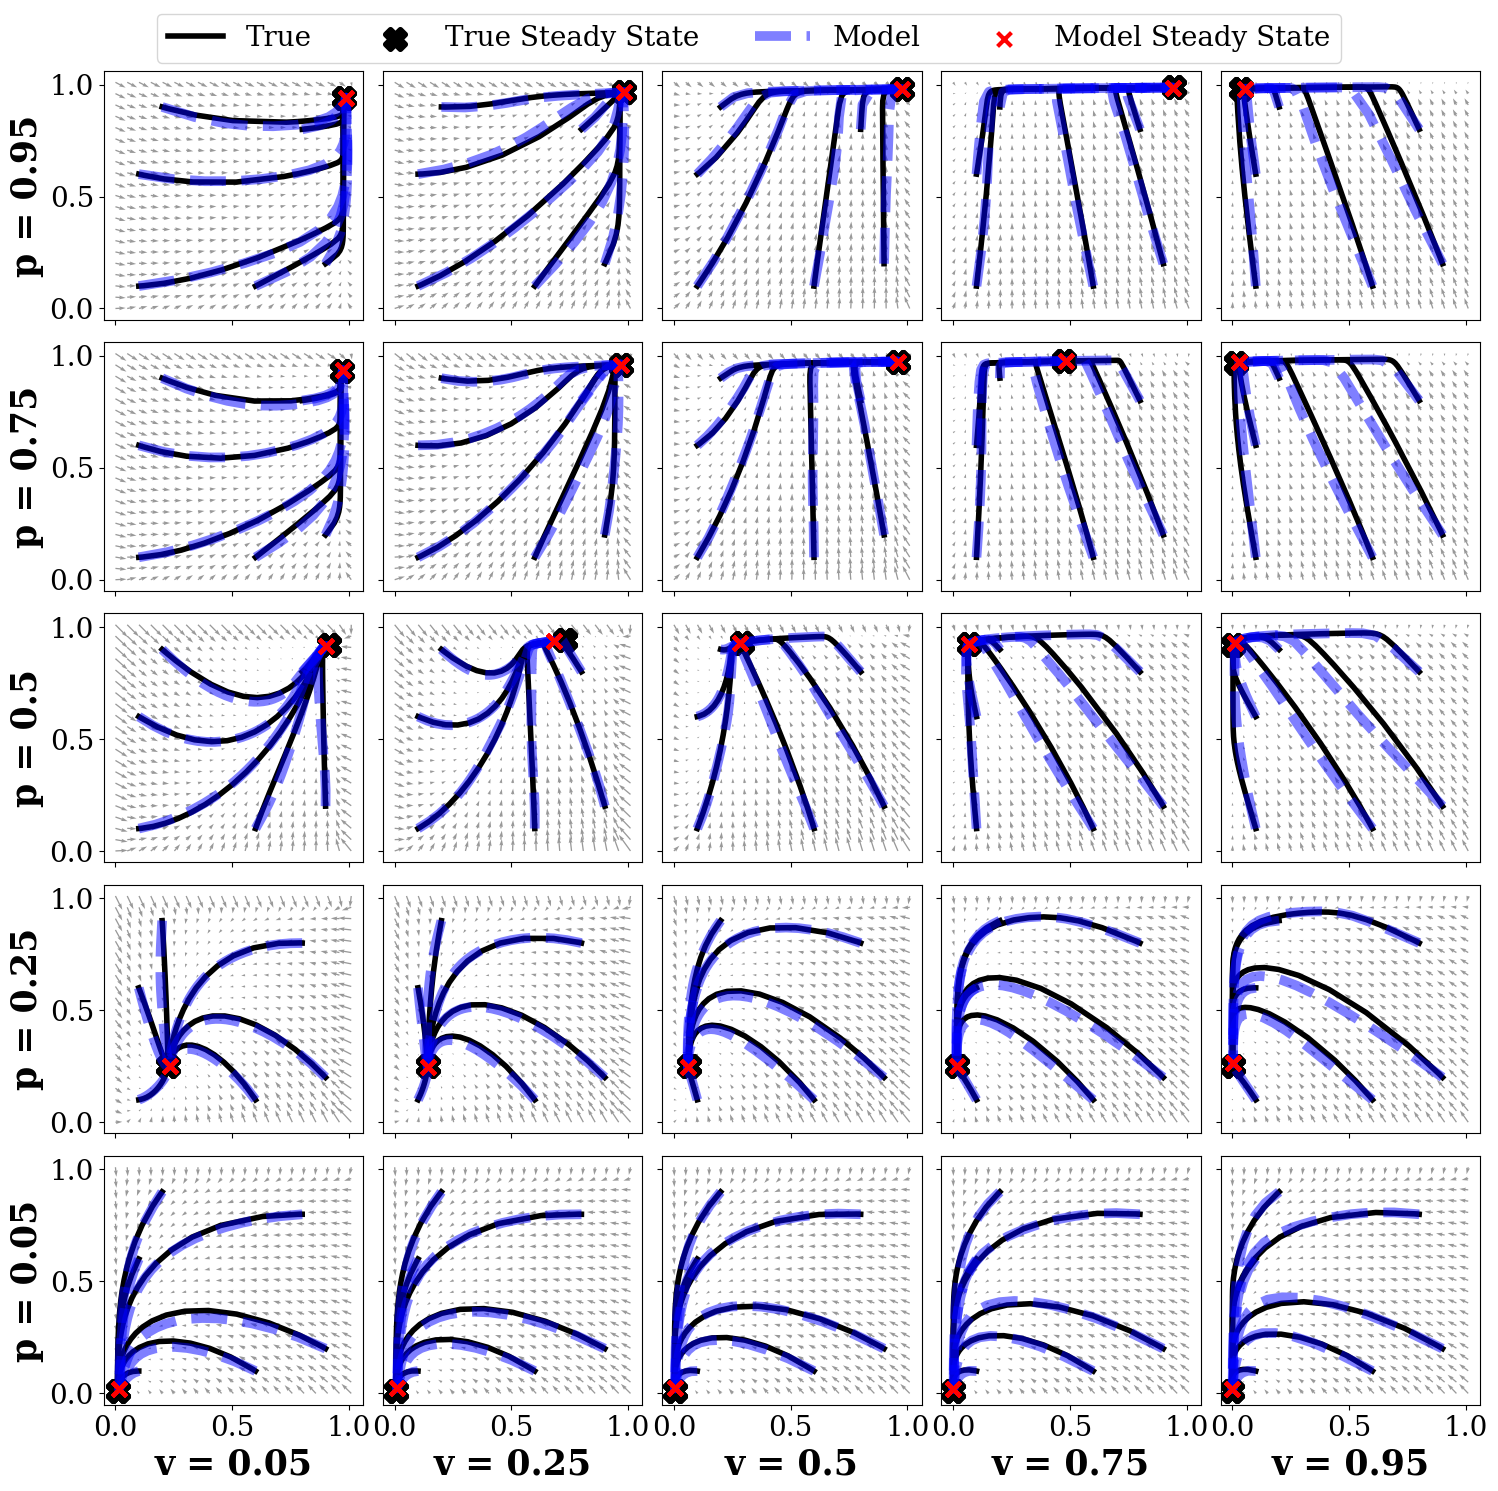

In [ ]:
fig_scale = 3
figsize = (int(fig_scale*len(p_vals)), int(fig_scale*len(v_vals)))

fig, axes = plt.subplots(
    len(p_vals), len(v_vals),
    figsize=figsize,
    # constrained_layout=True,
    sharex=True,
    sharey=True
)

Ti = torch.linspace(t_span[0], t_span[-1], 501, dtype=torch.float32)

for i, pi in enumerate(tqdm(p_vals[::-1])):
    for j, vj in enumerate(v_vals):
        ax = axes[i, j]

        # ======================================================
        # TRUE VECTOR FIELD
        # ======================================================
        U = np.zeros_like(X1)
        V = np.zeros_like(X2)

        for ii in range(X1.shape[0]):
            for jj in range(X1.shape[1]):
                x = np.array([X1[ii, jj], X2[ii, jj]])
                dxdt = two_tank_system(0, x, (pi, vj))
                U[ii, jj] = dxdt[0]
                V[ii, jj] = dxdt[1]

        ax.quiver(
            X1, X2, U, V,
            angles='xy',
            scale_units='xy',
            width=0.005,
            color='grey',
            alpha=0.8
        )

        # ======================================================
        # TRUE TRAJECTORIES (solid)
        # ======================================================
        for idx, x0 in enumerate(x_inits):
            label = None
            if idx ==0:
                label = "True"
            sol_true = sp_solve_ivp(
                lambda t, y: two_tank_system(t, y, (pi, vj)),
                t_span,
                x0,
                rtol=1e-6,
                atol=1e-9
            )

            ax.plot(
                sol_true.y[0],
                sol_true.y[1],
                '-',
                c='black',
                lw=4,
                zorder=1,
                label=label
            )
            label=None
            if idx ==0:
                label = "True Steady State"
            x_last = sol_true.y[:, -1]
            ax.scatter(
                x_last[0], x_last[1],
                marker='X',
                s=200,
                c='black',
                lw=4,
                zorder=3,
                label=label
            )

        # ======================================================
        # MODEL TRAJECTORIES (dashed)
        # ======================================================
        x0_torch = torch.tensor(x_inits, dtype=torch.float32)
        n_x0, dim_x0 = x0_torch.shape

        control = lambda t: torch.tensor([pi, vj], dtype=torch.float32).expand(n_x0, dim_x0)
        func = lambda t, x: model(t, x, control)

        with torch.no_grad():
            sol_model = torchode.solve_ivp(
                f=func,
                y0=x0_torch,
                t_eval=Ti,
            )

        for idx,traj in enumerate(sol_model.ys):
            label=None
            if idx ==0:
                label = "Model"
            ax.plot(
                traj[:, 0].numpy(),
                traj[:, 1].numpy(),
                '--',              # <-- dashed
                lw=7,
                color='blue',
                alpha=0.5,
                zorder=3,
                label = label
            )
            x_last = traj[-1,:].numpy()
            
            label = None
            if idx ==0:
                label = "Model Steady State"
            ax.scatter(x_last[0],x_last[1], marker='x',s=100,c='red',lw=3,zorder=4,label =label)


        # ======================================================
        # LABELS / FORMATTING
        # ======================================================
        if j == 0:
            ax.set_ylabel(f"p = {pi}", size=25, fontweight='bold')

        if i == len(v_vals) - 1:
            ax.set_xlabel(f"v = {vj}", size=25, fontweight='bold')

        ax.tick_params(axis='both', which='major', labelsize=20)

# plt.suptitle(
#     "Phase Portrait: True System (solid) vs Model (dashed)",
#     size=60
# )

handles, labels = axes[0,0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=5,fontsize=20)

plt.tight_layout(rect=[0,0,1,0.96])
plt.savefig("mixing-tanks-phase-portrait.png")
plt.show()
